In [ ]:
#read in adata objects
import anndata as ad
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
from upsetplot import from_contents
import seaborn as sns

In [ ]:
#read in annotated h5ad
adatas = ad.read_h5ad('../data/background_removed/all_organs_annotated_5_1_26.h5ad')

### Subsetting RPG to cluster and remove background

In [6]:
rpg_only = adatas[adatas.obs['organ'] == 'RPG', :].copy()
rpg_only

AnnData object with n_obs × n_vars = 14963 × 931
    obs: 'name', 'spotId', 'x', 'y', 'leiden', 'organ', 'border_or_tissue', 'leiden_backup'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dendrogram_leiden', 'dendrogram_organ', 'hvg', 'leiden', 'log1p', 'name', 'neighbors', 'organ_colors', 'pca', 'rank_mz_leiden', 'rank_mz_organ', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [34]:
sc.tl.leiden(rpg_only, resolution=0.5, key_added='leiden_rpg')

/var/folders/ft/9cnhb36s19ld2jkvqs5qst1r0000gn/T/ipykernel_37120/2427125857.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rpg_only, resolution=0.5, key_added='leiden_rpg')


/var/folders/ft/9cnhb36s19ld2jkvqs5qst1r0000gn/T/ipykernel_37120/2538914781.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sc.pl.scatter(rpg_only, x='x', y='y', color='leiden_rpg', show=False, title=rpg_only.obs['name'][0])


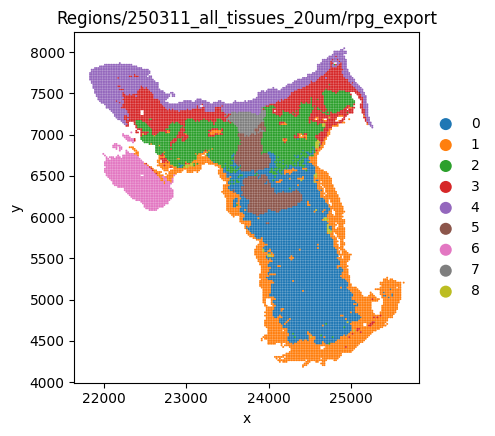

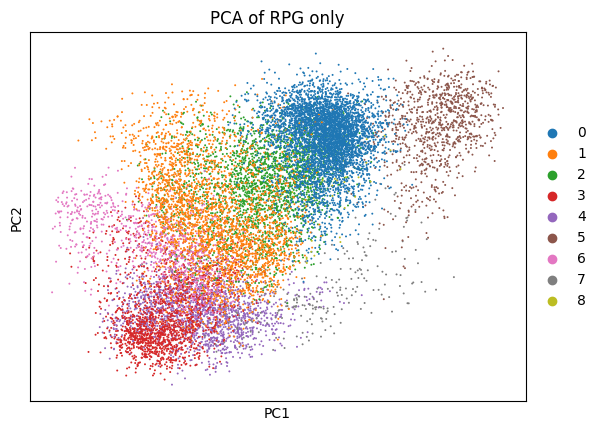

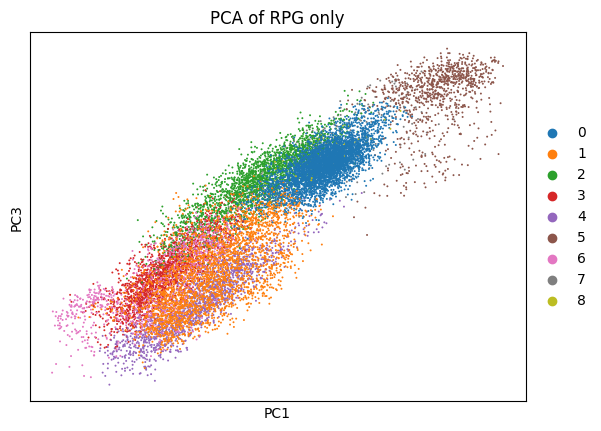

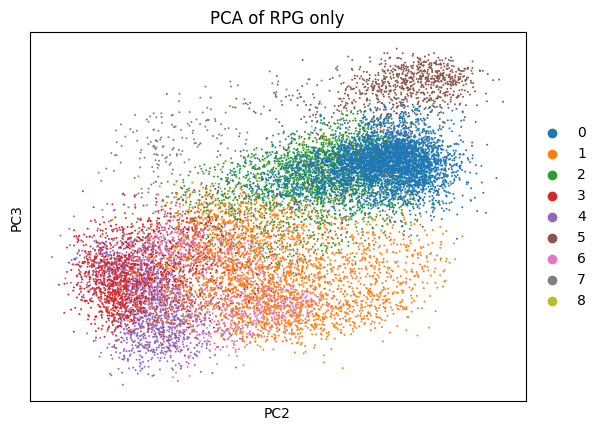

In [36]:
sc.pl.scatter(rpg_only, x='x', y='y', color='leiden_rpg', show=False, title=rpg_only.obs['name'][0])
plt.gca().set_aspect('equal', adjustable='box')
sc.pl.pca(rpg_only, color='leiden_rpg', show=True, title='PCA of RPG only')
sc.pl.pca(rpg_only, color='leiden_rpg', show=True, title='PCA of RPG only', components=['1,3'])
sc.pl.pca(rpg_only, color='leiden_rpg', show=True, title='PCA of RPG only', components=['2,3'])

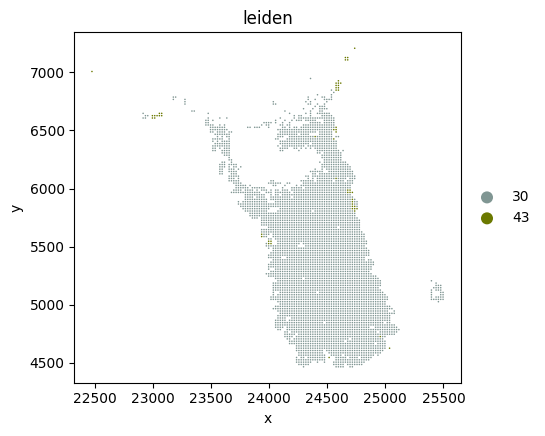

In [48]:
#mask = (

#    (~rpg_only.obs['leiden_rpg'].isin([ '1','26' , '29', '13',  '5','7', '16', '24', '23', '17', '21', '20',
 #                                      '11', '36', '27','32' , '37'])) #'31' -> border, 22 potentially border
    #(all_organs.obs['leiden'].isin([ '27','32' ,'33','34','36' ,'37']))
#)
#mask = rpg_only.obs['leiden_rpg'].isin(['5', '11', '6', '10', '9']) 
#mask = rpg_only.obs['leiden_rpg'].isin(['3', '4', '8', '2', '0', '1', '7', '12','13'])
mask = rpg_only.obs['leiden'].isin([ '30','43'])

# subset the AnnData and plot the filtered spots
subset = rpg_only[mask, :].copy()
sc.pl.scatter(subset, x='x', y='y', color='leiden', show=False, size=5)
plt.gca().set_aspect('equal', adjustable='box')

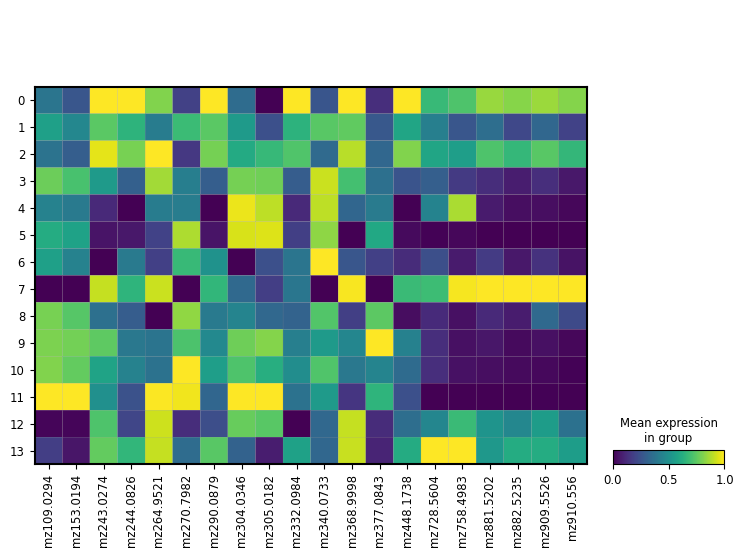

In [184]:

sc.pl.matrixplot(rpg_only[rpg_only.obs['organ'] == 'RPG'], var_names=highly_variable_genes.index, groupby='leiden_rpg', use_raw=False, standard_scale='var', show=True)

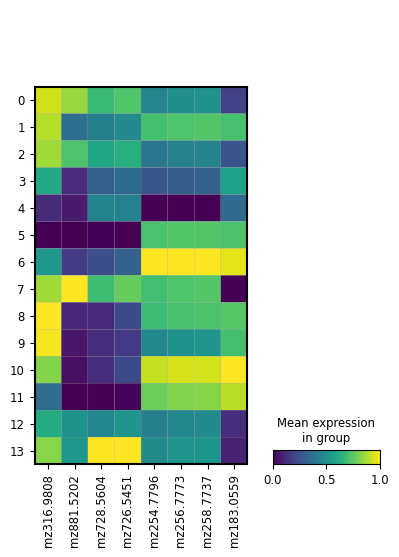

In [183]:
sc.pl.matrixplot(rpg_only[rpg_only.obs['organ'] == 'RPG'], var_names=['mz316.9808', 'mz881.5202', 'mz728.5604', 'mz726.5451', 'mz254.7796','mz256.7773', 'mz258.7737','mz183.0559',], groupby='leiden_rpg', use_raw=False, standard_scale='var', show=True)

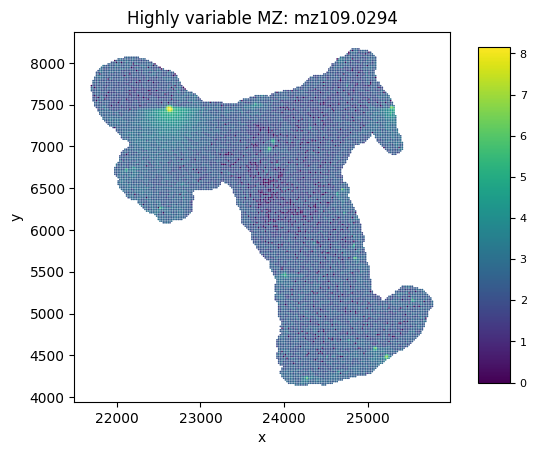

<Figure size 640x480 with 0 Axes>

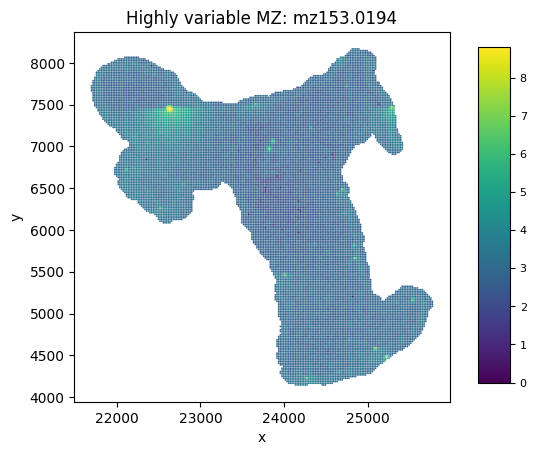

<Figure size 640x480 with 0 Axes>

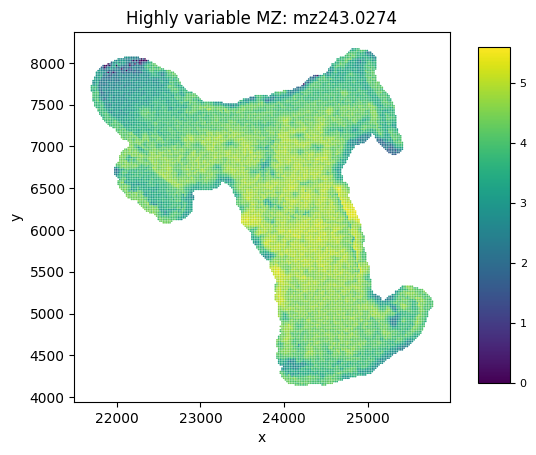

<Figure size 640x480 with 0 Axes>

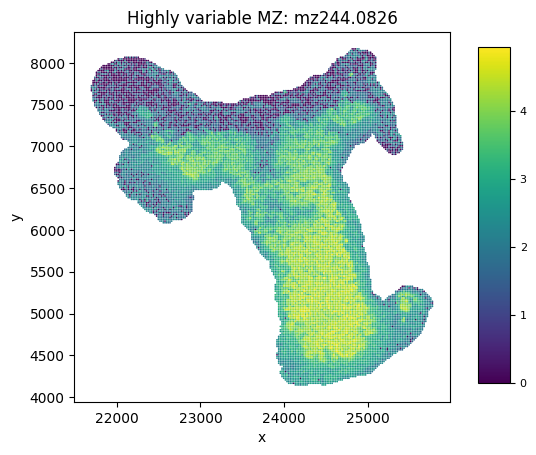

<Figure size 640x480 with 0 Axes>

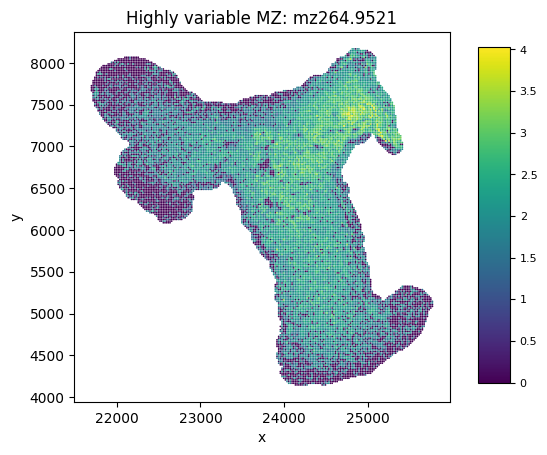

<Figure size 640x480 with 0 Axes>

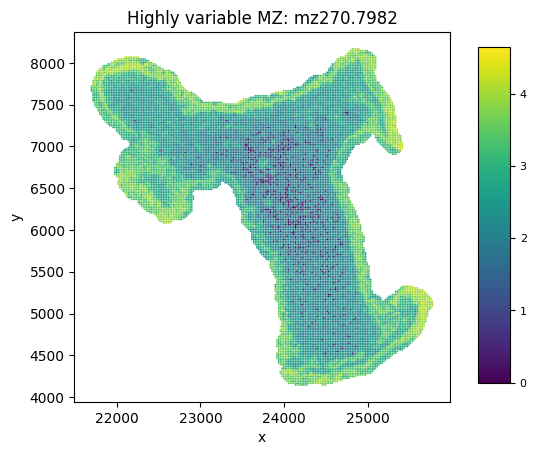

<Figure size 640x480 with 0 Axes>

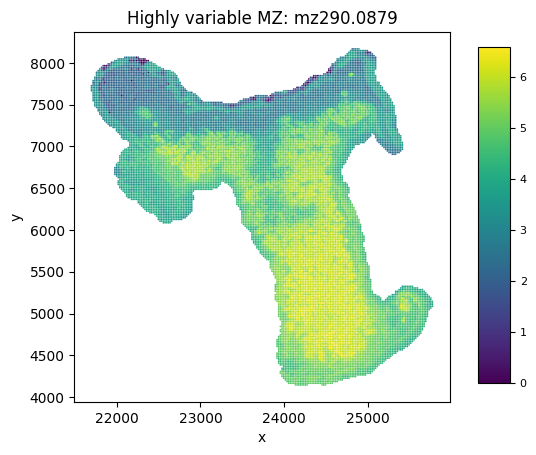

<Figure size 640x480 with 0 Axes>

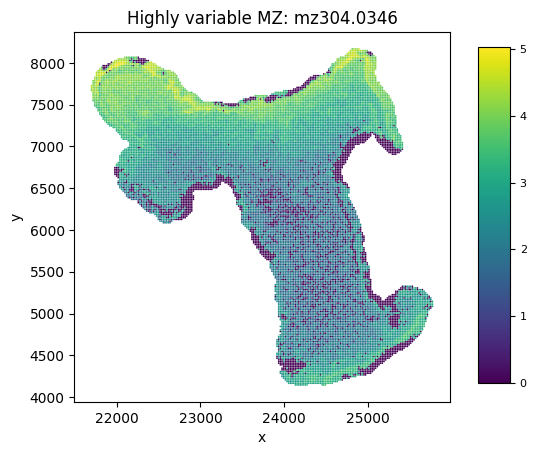

<Figure size 640x480 with 0 Axes>

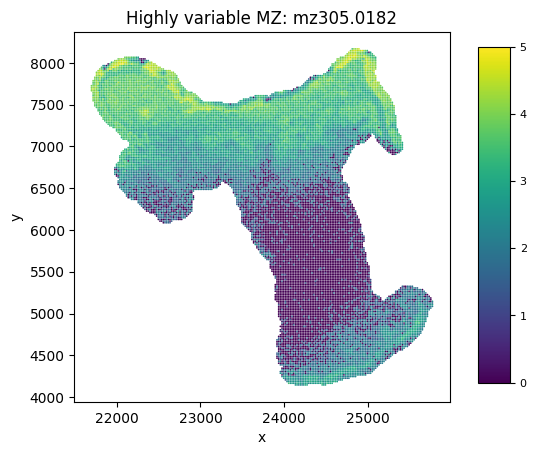

<Figure size 640x480 with 0 Axes>

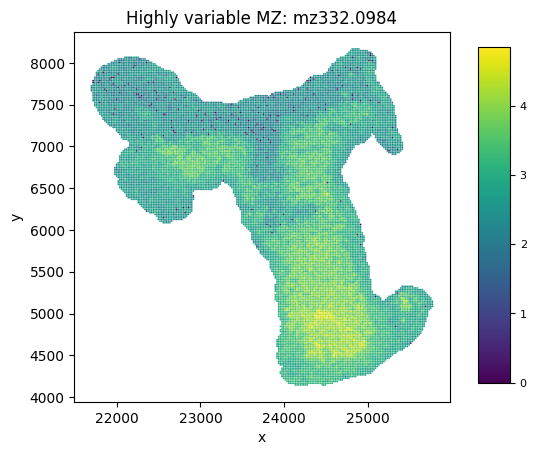

<Figure size 640x480 with 0 Axes>

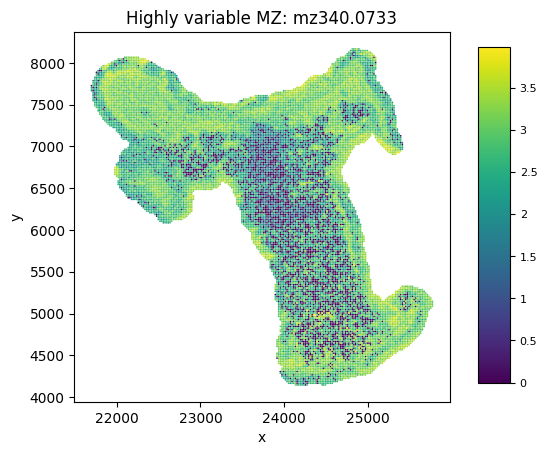

<Figure size 640x480 with 0 Axes>

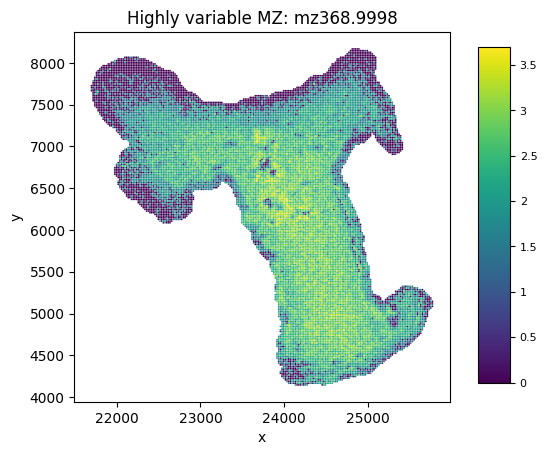

<Figure size 640x480 with 0 Axes>

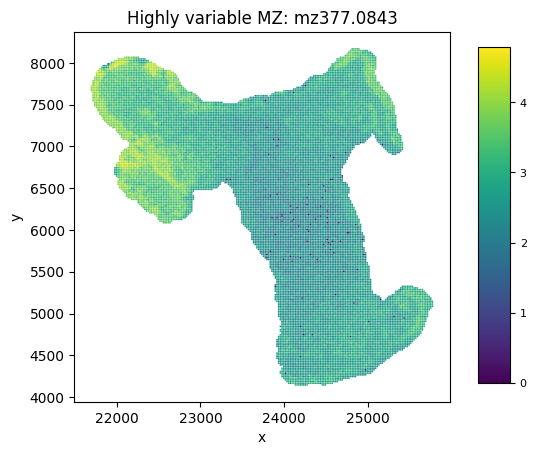

<Figure size 640x480 with 0 Axes>

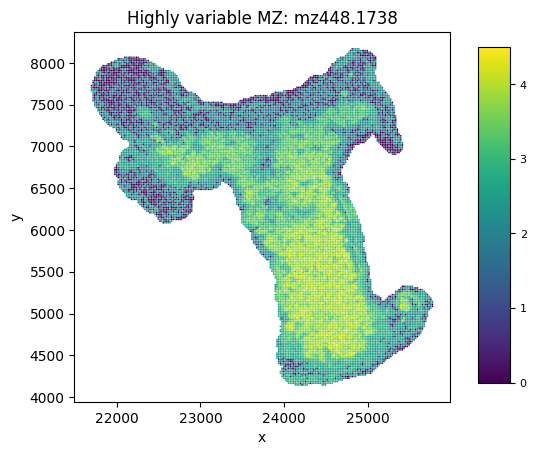

<Figure size 640x480 with 0 Axes>

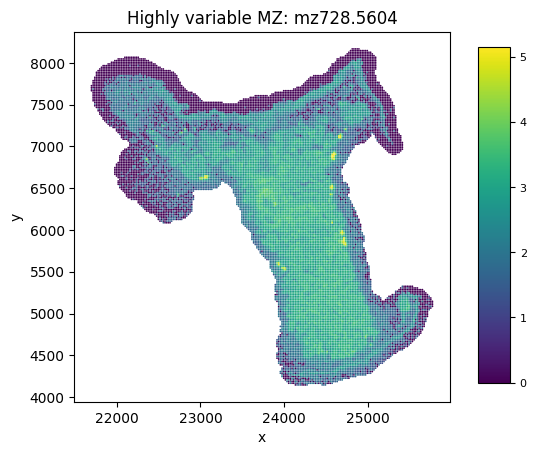

<Figure size 640x480 with 0 Axes>

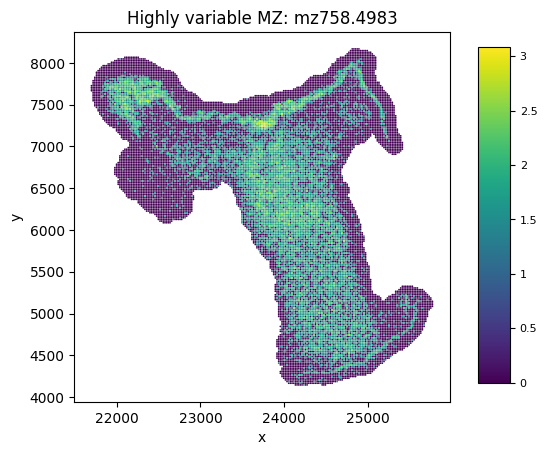

<Figure size 640x480 with 0 Axes>

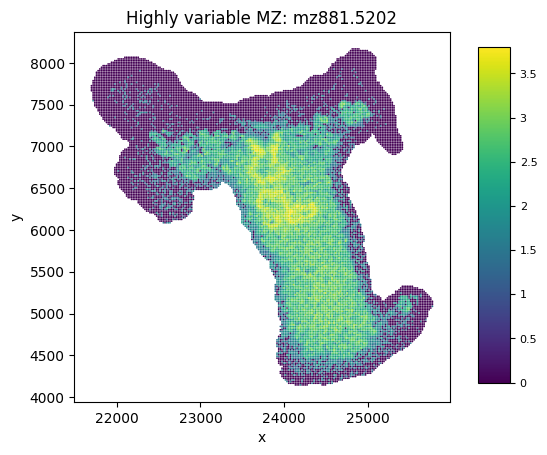

<Figure size 640x480 with 0 Axes>

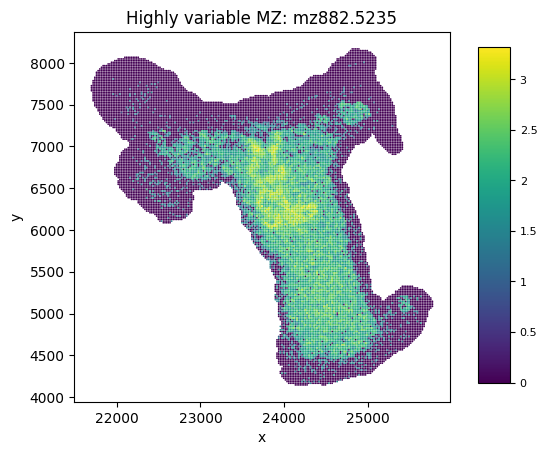

<Figure size 640x480 with 0 Axes>

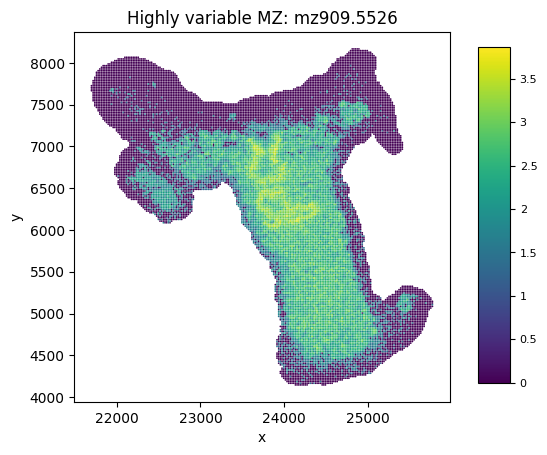

<Figure size 640x480 with 0 Axes>

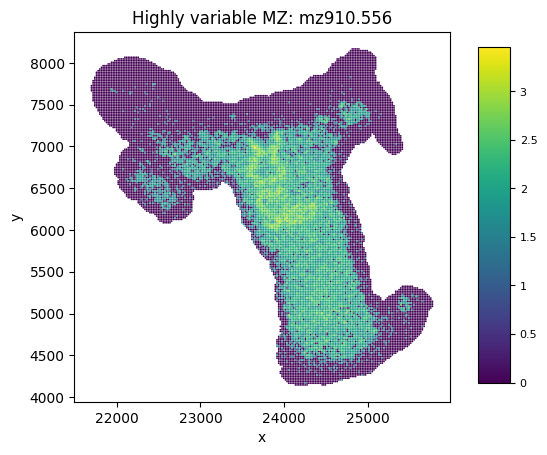

<Figure size 640x480 with 0 Axes>

In [182]:
for i, mz in enumerate(highly_variable_genes.index):
    fig, ax = plt.subplots()
    sc.pl.scatter(rpg_only, x='x', y='y', color=mz, title=f'Highly variable MZ: {mz}', show=False, ax=ax)
    ax.set_aspect('equal')
    #keep only 5 x axis ticks
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    #cb.ax.set_title('Intensity', fontsize=12, pad=5)
    cb.ax.set_position([0.85, 0.15, 0.05, 0.7])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

### incorporate new clusters to adatas

In [ ]:
rpg_only.obs['leiden_rpg'] = rpg_only.obs['leiden_rpg'].astype(int)
rpg_only.obs['leiden_rpg'] = rpg_only.obs['leiden_rpg'] +30
rpg_only.obs['leiden_rpg'] = rpg_only.obs['leiden_rpg'].astype('category')
rpg_only.obs['leiden_rpg'].unique()

[35, 34, 33, 41, 32, ..., 36, 43, 37, 38, 30]
Length: 14
Categories (14, int64): [30, 31, 32, 33, ..., 40, 41, 42, 43]

In [207]:
rpg_only.obs
# add leiden_rpg cluster to adatas.obs['leiden'], overwriting the old values for the RPG organ only
# match by spotId to ensure correct assignment

adatas.obs['leiden'] = adatas.obs['leiden'].astype(str)
adatas.obs.loc[adatas.obs['organ'] == 'RPG', 'leiden'] = rpg_only.obs['leiden_rpg'].values.astype(str)
adatas.obs['leiden'] = adatas.obs['leiden'].astype('category')
adatas.obs['leiden'].unique()

['13', '6', '5', '10', '20', ..., '4', '3', '1', '11', '14']
Length: 37
Categories (37, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']

In [249]:
#make new column assigning border or tissue based on leiden clusters
adatas.obs['border_or_tissue'] = 'tissue'
adatas.obs.loc[adatas.obs['leiden'].isin(['35', '41', '36', '40', '39', '21']), 'border_or_tissue'] = 'border'
adatas.obs.loc[adatas.obs['leiden'].isin(['15', '22']), 'border_or_tissue'] = 'border' # call 15 and 22 border as well so they get removed. Former RPG clusters that were now split into new clusters

In [250]:
#remove background clusters
remove_background = adatas.obs['border_or_tissue'] == 'tissue'
#sc.pl.scatter(adatas[remove_background, :], x='x', y='y', color='leiden', show=False)
#plt.gcf().set_size_inches(15, 15)
#plt.gca().set_aspect('equal', adjustable='box')
adatas = adatas[remove_background, :].copy()

In [ ]:
#save cleaned adata object
#all_organs.write_h5ad('../data/background_removed/clean_all_organs_no_border_processed.h5ad')
#all_organs.obs.to_csv('../data/background_removed/clean_all_organs_no_border_obs.csv')

In [ ]:
# subsetting all_organs csv to only include tissue spots
raw = pd.read_csv('../data/raw/250311_all_tissues_20um_RMS.csv')
#subset raw to only include tissue by spotId
clean_raw = raw[raw['spotId'].isin(all_organs.obs['spotId'])].copy()
# save clean_raw to csv
clean_raw.to_csv('../data/background_removed/clean_all_organs_no_border_raw.csv', index=False)
clean_raw

,name,spotId,x,y,mz78.9589,mz79.9571,mz80.9644,mz81.9527,mz85.0292,mz87.0084,...,mz911.565,mz912.5705,mz913.5817,mz914.585,mz915.4771,mz919.5095,mz943.5108,mz944.5138,mz945.5108,mz959.4837
264,Regions/250311_all_tissues_20um/smg_export,250730,47396.781250,10846.380859,504.956299,80.826416,10.671685,7.702173,5.243045,56.095943,...,4.036681,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,5.428640,0.000000,0.000000
352,Regions/250311_all_tissues_20um/smg_export,250818,47396.781250,10826.380859,370.923859,135.501907,11.151959,8.317348,13.762786,65.046883,...,3.132992,0.000000,0.000000,0.000000,0.0,2.349744,2.909207,0.000000,2.946504,0.000000
353,Regions/250311_all_tissues_20um/smg_export,250819,47416.781250,10826.380859,440.920807,102.123169,13.242905,9.974624,4.456747,60.908875,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
356,Regions/250311_all_tissues_20um/smg_export,250822,47476.781250,10826.380859,469.715332,111.334068,0.000000,4.187241,7.350933,61.598957,...,0.000000,2.931068,0.000000,3.442842,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
440,Regions/250311_all_tissues_20um/smg_export,250906,47236.781250,10806.380859,515.446960,91.616142,14.129185,0.000000,0.000000,62.329380,...,4.337123,3.889997,3.308733,0.000000,0.0,0.000000,4.113560,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511443,Regions/250311_all_tissues_20um/spleen_export,92549,2136.780273,666.381348,533.743347,147.006485,24.022837,7.541226,3.082891,13.849296,...,2.466313,1.754876,2.703458,3.059177,0.0,1.494017,3.604611,3.154035,0.000000,0.000000
511444,Regions/250311_all_tissues_20um/spleen_export,92550,2156.780273,666.381348,507.373749,148.992599,10.835390,13.897046,4.520726,6.195069,...,2.344080,0.000000,3.827070,3.468282,0.0,0.000000,3.205171,2.080969,0.000000,0.000000
511445,Regions/250311_all_tissues_20um/spleen_export,92551,2176.780273,666.381348,481.793579,152.557541,9.893996,4.101258,3.684181,9.222038,...,1.853676,2.131727,4.726874,1.853676,0.0,0.000000,2.039044,1.784163,1.784163,0.000000
511446,Regions/250311_all_tissues_20um/spleen_export,92552,2196.780273,666.381348,504.901733,159.256561,14.443675,4.864710,5.993122,5.441454,...,1.830535,0.000000,2.632962,1.680080,0.0,0.000000,3.084327,2.031142,0.000000,1.955914


### merge clusters to be more meaningfull

In [6]:
parotid_only = adatas[adatas.obs['organ'] == 'parotid', :].copy()
smg_only = adatas[adatas.obs['organ'] == 'SMG', :].copy()
slg_only = adatas[adatas.obs['organ'] == 'SLG', :].copy()
rpg_only = adatas[adatas.obs['organ'] == 'RPG', :].copy()
spleen_only = adatas[adatas.obs['organ'] == 'spleen', :].copy()
pancreas_only = adatas[adatas.obs['organ'] == 'pancreas', :].copy()

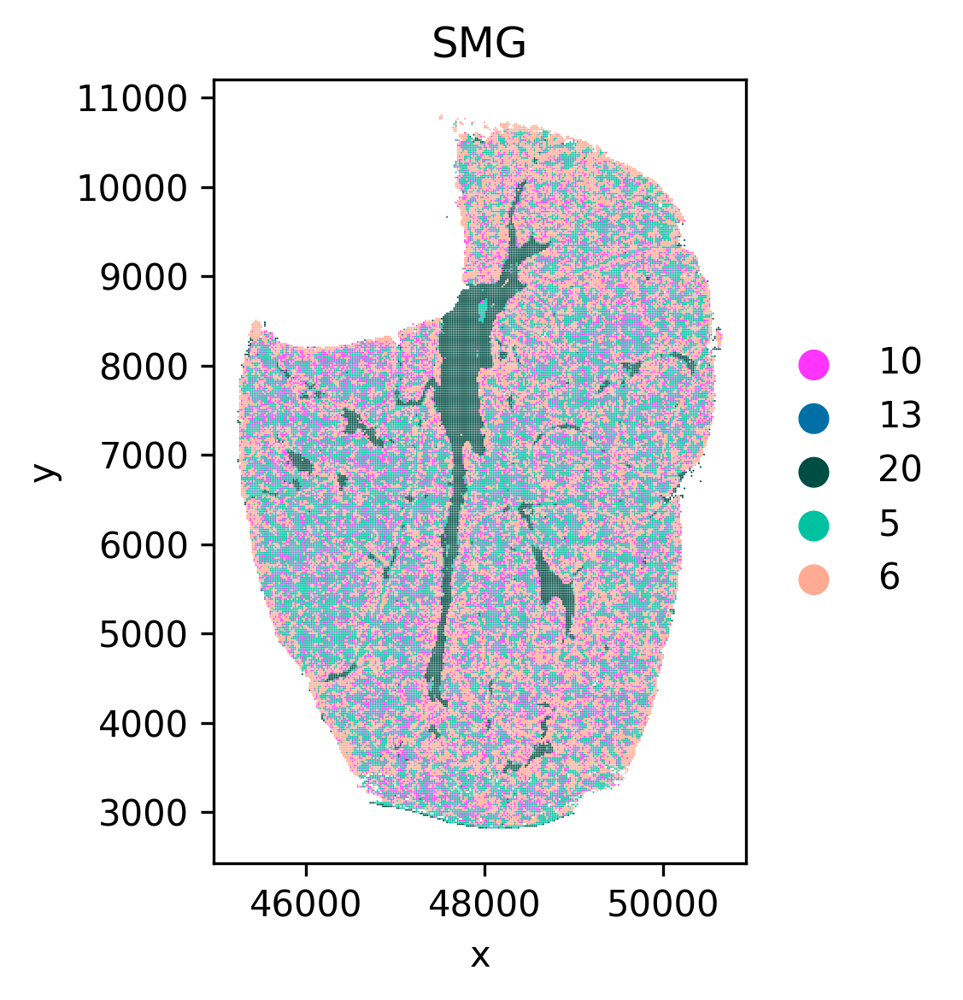

In [7]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
sc.pl.scatter(smg_only, x='x', y='y', color='leiden', show=False, title='SMG', ax=ax, size = 1)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

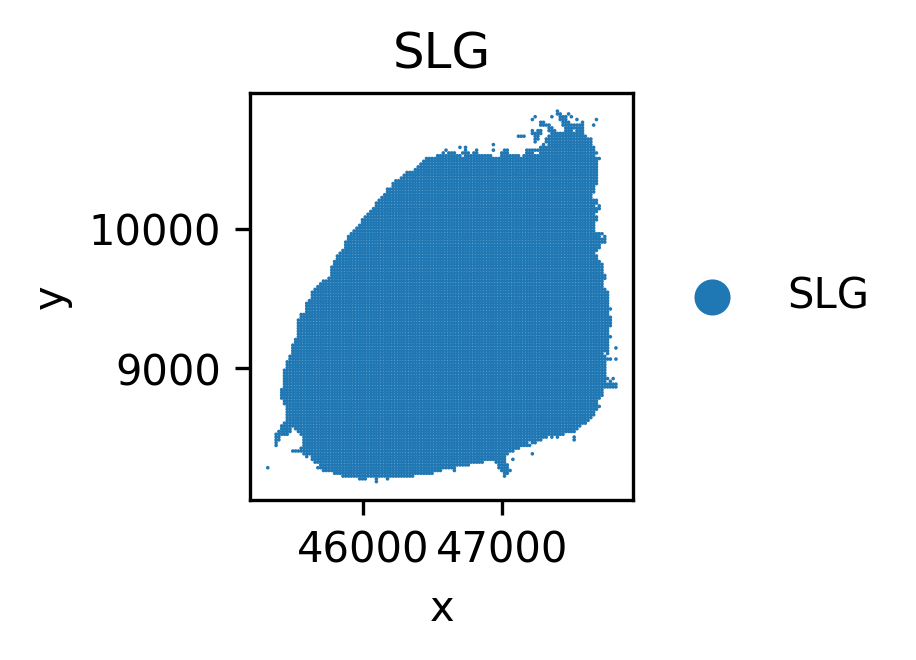

In [16]:
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
sc.pl.scatter(slg_only, x='x', y='y', color='leiden', show=False, title='SLG', ax=ax, size = 3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

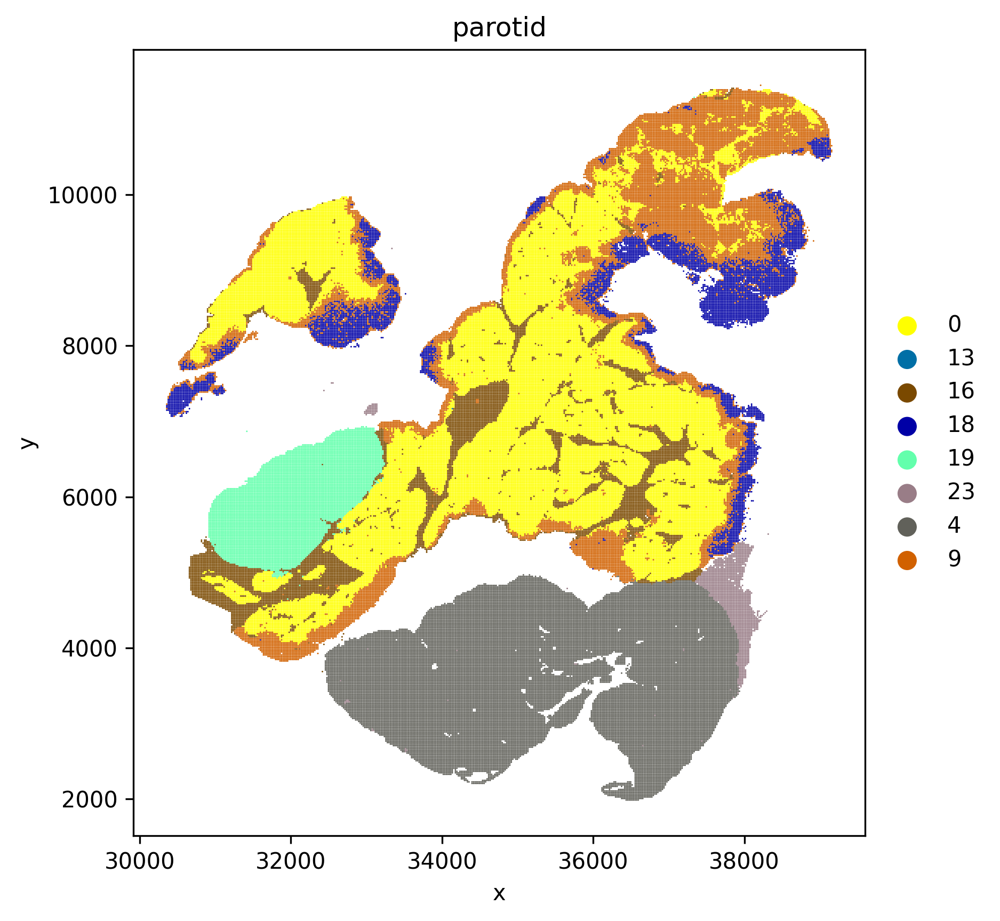

In [8]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
sc.pl.scatter(parotid_only, x='x', y='y', color='leiden', show=False, title='parotid', ax=ax, size = 2)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

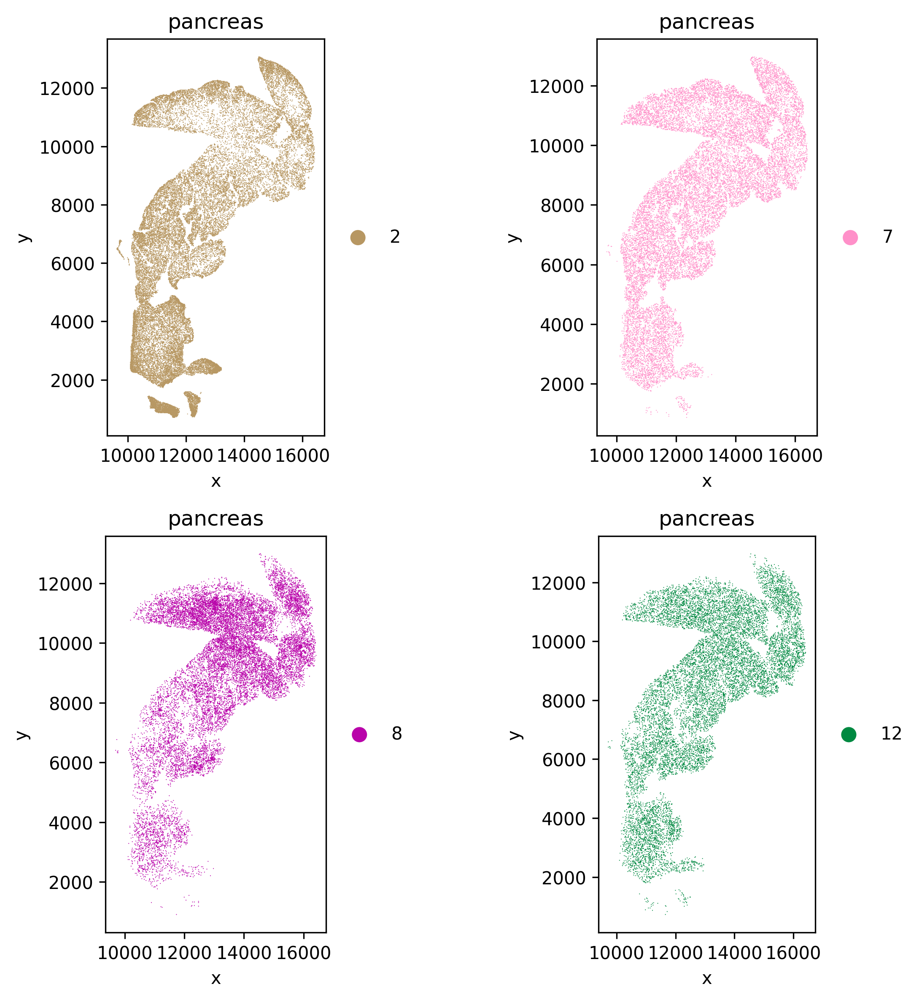

In [18]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), dpi=300)
# plot all 4 pancreas clusters separately, in a 2x2 grid
sc.pl.scatter(pancreas_only[pancreas_only.obs['leiden'] =='2'], x='x', y='y', color='leiden', show=False, title='pancreas', ax=ax[0, 0], size = 1)
sc.pl.scatter(pancreas_only[pancreas_only.obs['leiden'] =='7'], x='x', y='y', color='leiden', show=False, title='pancreas', ax=ax[0, 1], size = 1)
sc.pl.scatter(pancreas_only[pancreas_only.obs['leiden'] =='8'], x='x', y='y', color='leiden', show=False, title='pancreas', ax=ax[1, 0], size = 1)
sc.pl.scatter(pancreas_only[pancreas_only.obs['leiden'] =='12'], x='x', y='y', color='leiden', show=False, title='pancreas', ax=ax[1, 1], size = 1)
ax[0,0].set_aspect('equal')
ax[0,1].set_aspect('equal')
ax[1,0].set_aspect('equal')
ax[1,1].set_aspect('equal')
plt.tight_layout()
plt.show()

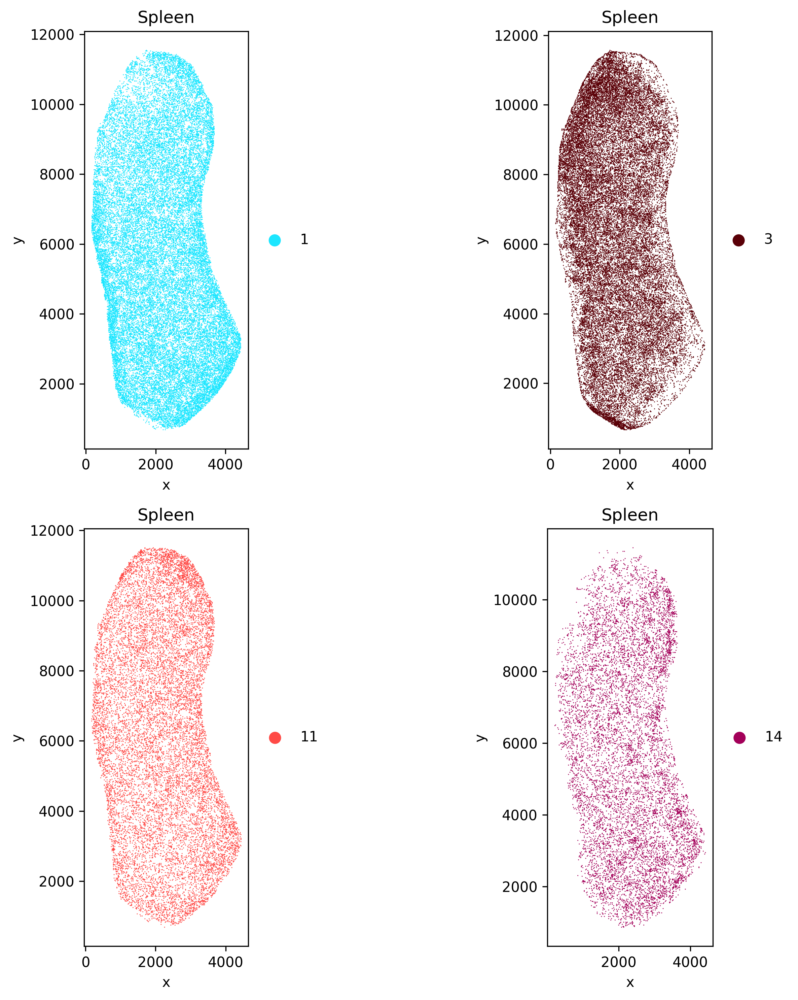

In [25]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(figsize=(10,10), nrows =2, ncols=2, dpi=300)
sc.pl.scatter(spleen_only[spleen_only.obs['leiden'] =='1'], x='x', y='y', color='leiden', show=False, title='Spleen', ax=ax1, size = 2)
sc.pl.scatter(spleen_only[spleen_only.obs['leiden'] =='3'], x='x', y='y', color='leiden', show=False, title='Spleen', ax=ax2, size = 2)
sc.pl.scatter(spleen_only[spleen_only.obs['leiden'] =='11'], x='x', y='y', color='leiden', show=False, title='Spleen', ax=ax3, size = 2)
sc.pl.scatter(spleen_only[spleen_only.obs['leiden'] =='14'], x='x', y='y', color='leiden', show=False, title='Spleen', ax=ax4, size = 2)
ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')
ax4.set_aspect('equal')
plt.tight_layout()
plt.show()

/Users/margotchazotte/anaconda3/envs/clustering-env/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


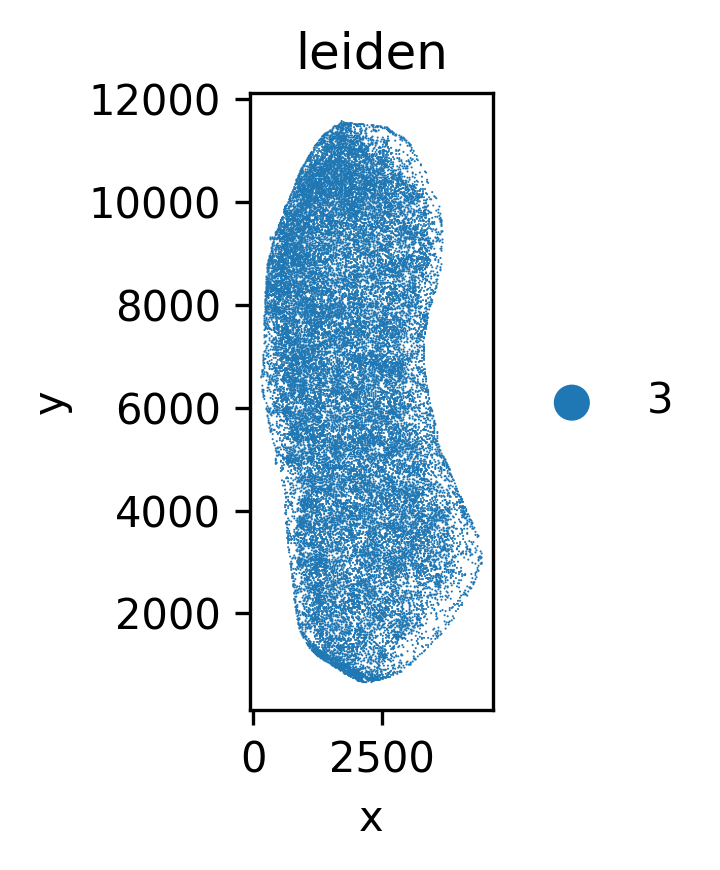

In [136]:
#plot clusters on x and y coordinates
mask = (
    (adatas.obs['leiden'].isin([ '3']))
)

# subset the AnnData and plot the filtered spots
subset = adatas[mask]
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
sc.pl.scatter(subset, x='x', y='y', color='leiden', show=False, size=1, ax=ax)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [3]:
# change organ baser on cluster assignment
for cluster, organ in [('6', 'SMG'), ('10', 'SMG'), ('20', 'SMG'), ('13', 'SLG')]:
    adatas.obs.loc[adatas.obs['leiden'] == cluster, 'organ'] = organ
# remove spot with Organ == 'SLG' and x < 35000
adatas = adatas[~((adatas.obs['organ'] == 'SLG') & (adatas.obs['x'] < 35000)), :].copy()
# merge and rename clusters to be descriptive
#adatas.obs['leiden'] = adatas.obs['leiden_backup'].copy()
adatas.obs['leiden_backup'] = adatas.obs['leiden'].copy()

adatas.obs['leiden'] = adatas.obs['leiden'].astype(str)
adatas.obs.loc[adatas.obs['leiden'].isin(['32']), 'leiden'] = 'RPG secretory'
adatas.obs.loc[adatas.obs['leiden'].isin(['30']), 'leiden'] = 'RPG secretory'
adatas.obs.loc[adatas.obs['leiden'].isin(['43']), 'leiden'] = 'RPG secretory'
adatas.obs.loc[adatas.obs['leiden'].isin(['33']), 'leiden'] = 'RPG epithelial'
adatas.obs.loc[adatas.obs['leiden'].isin(['34']), 'leiden'] = 'RPG epithelial'
adatas.obs.loc[adatas.obs['leiden'].isin(['37']), 'leiden'] = 'RPG nerve'
adatas.obs.loc[adatas.obs['leiden'].isin(['42']), 'leiden'] = 'RPG nerve'
adatas.obs.loc[adatas.obs['leiden'].isin(['31']), 'leiden'] = 'RPG border'
adatas.obs.loc[adatas.obs['leiden'].isin(['38']), 'leiden'] = 'RPG muscle'
adatas.obs.loc[adatas.obs['leiden'].isin(['13']), 'leiden'] = 'SLG'
adatas.obs.loc[adatas.obs['leiden'].isin(['20']), 'leiden'] = 'SMG duct and vessels'
adatas.obs.loc[adatas.obs['leiden'].isin(['6']), 'leiden'] = 'SMG ducts'
adatas.obs.loc[adatas.obs['leiden'].isin(['5']), 'leiden'] = 'SMG acinar'
adatas.obs.loc[adatas.obs['leiden'].isin(['10']), 'leiden'] = 'SMG acinar'
adatas.obs.loc[adatas.obs['leiden'].isin(['18']), 'leiden'] = 'parotid border'
adatas.obs.loc[adatas.obs['leiden'].isin(['23']), 'leiden'] = 'parotid border'
adatas.obs.loc[adatas.obs['leiden'].isin(['4']), 'leiden'] = 'parotid dense'
adatas.obs.loc[adatas.obs['leiden'].isin(['19']), 'leiden'] = 'parotid lymph node'
adatas.obs.loc[adatas.obs['leiden'].isin(['16']), 'leiden'] = 'parotid connective and ducts'
adatas.obs.loc[adatas.obs['leiden'].isin(['9']), 'leiden'] = 'parotid undefined'
adatas.obs.loc[adatas.obs['leiden'].isin(['0']), 'leiden'] = 'parotid main'
adatas.obs.loc[adatas.obs['leiden'].isin(['2']), 'leiden'] = 'pancreas 1'
adatas.obs.loc[adatas.obs['leiden'].isin(['7']), 'leiden'] = 'pancreas 1'
adatas.obs.loc[adatas.obs['leiden'].isin(['8']), 'leiden'] = 'pancreas 2'
adatas.obs.loc[adatas.obs['leiden'].isin(['12']), 'leiden'] = 'pancreas 2'
adatas.obs.loc[adatas.obs['leiden'].isin(['1']), 'leiden'] = 'spleen 1'
adatas.obs.loc[adatas.obs['leiden'].isin(['11']), 'leiden'] = 'spleen 1'
adatas.obs.loc[adatas.obs['leiden'].isin(['3']), 'leiden'] = 'spleen 2'
adatas.obs.loc[adatas.obs['leiden'].isin(['14']), 'leiden'] = 'spleen 1'


adatas.obs['leiden'] = adatas.obs['leiden'].astype('category')
adatas.obs['leiden'].unique()

['SLG', 'SMG ducts', 'SMG acinar', 'SMG duct and vessels', 'pancreas 1', ..., 'parotid lymph node', 'parotid border', 'parotid dense', 'spleen 2', 'spleen 1']
Length: 19
Categories (19, object): ['RPG border', 'RPG epithelial', 'RPG muscle', 'RPG nerve', ..., 'parotid main', 'parotid undefined', 'spleen 1', 'spleen 2']

### palette

In [5]:
palette = [
    "#191970",  # midnightblue
    "#dc143c",  # NEW: crimson (deep red)
    "#2ca02c",  # green
    "#9467bd",  # purple   
    "#41B3A3",   # mint teal
    "#ff7f0e"  # orange  
]

clusters = adatas.obs['organ'].cat.categories
adatas.uns['organ_colors'] = palette[:len(clusters)]

### Plot exports

In [7]:
# Randomly re-order the data for plotting
random_indices = np.random.default_rng(0).permutation(list(range(adatas.shape[0])))

In [ ]:
#plot adatas UMAP and PCA with organ colors as svg
sc.pl.umap(adatas[random_indices, :], color='organ', title='UMAP: all tissues - organ', size = 1, save="_all_tissues_organ.svg")
sc.pl.umap(adatas[random_indices, :], color='leiden', title='UMAP: all tissues - leiden clusters', size = 1, save="_all_tissues_leiden.svg")

#plot PCs
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: all tissues - organ', annotate_var_explained=True, components=['1,2'], size=2.5, save="_all_tissues_organ_components_1_2.svg")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: all tissues - leiden clusters', annotate_var_explained=True, components=['1,2'], size=2.5, save="_all_tissues_leiden_components_1_2.svg")
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: all tissues - organ', annotate_var_explained=True, components=['1,3'], size=2.5, save="_all_tissues_organ_components_1_3.svg")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: all tissues - leiden clusters', annotate_var_explained=True, components=['1,3'], size=2.5, save="_all_tissues_leiden_components_1_3.svg")
sc.pl.pca(adatas[random_indices, :], color='organ', title='PCA: all tissues - organ', annotate_var_explained=True, components=['2,3'], size=2.5, save="_all_tissues_organ_components_2_3.svg")
sc.pl.pca(adatas[random_indices, :], color='leiden', title='PCA: all tissues - leiden clusters', annotate_var_explained=True, components=['2,3'], size=2.5, save="_all_tissues_leiden_components_2_3.svg")

### filter for secretory clusters 

In [8]:
#filter out clusters corresponding to border and connective tissue
remove_border = adatas.obs['leiden'].isin(['RPG border', 'parotid border', 'parotid undefined', 'parotid lymph node', 'RPG muscle', 'RPG epithelial'])
adatas_sub = adatas[~remove_border, :].copy()
random_indices_sub = np.random.default_rng(0).permutation(list(range(adatas_sub.shape[0])))

In [ ]:
#plot subset adatas UMAP and PCA with organ colors, plot as PDF
sc.pl.umap(adatas_sub[random_indices_sub, :], color='organ', title='UMAP: filtered all tissues - organ', size = 1, save="_filtered_all_tissues_organ.pdf")
sc.pl.umap(adatas_sub[random_indices_sub, :], color='leiden', title='UMAP: filtered all tissues - leiden clusters', size = 1, save="_filtered_all_tissues_leiden.pdf")

#plot PCs
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: filtered all tissues - organ', annotate_var_explained=True, components=['1,2'], size=2.5, save="_filtered_all_tissues_organ_components_1_2.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: filtered all tissues - leiden clusters', annotate_var_explained=True, components=['1,2'], size=2.5, save="_filtered_all_tissues_leiden_components_1_2.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: filtered all tissues - organ', annotate_var_explained=True, components=['1,3'], size=2.5, save="_filtered_all_tissues_organ_components_1_3.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: filtered all tissues - leiden clusters', annotate_var_explained=True, components=['1,3'], size=2.5, save="_filtered_all_tissues_leiden_components_1_3.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: filtered all tissues - organ', annotate_var_explained=True, components=['2,3'], size=2.5, save="_filtered_all_tissues_organ_components_2_3.pdf")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: filtered all tissues - leiden clusters', annotate_var_explained=True, components=['2,3'], size=2.5, save="_filtered_all_tissues_leiden_components_2_3.pdf")
#sc.pl.pca(adatas_sub, color='organ', title='PCA: filtered all tissues - organ', annotate_var_explained=True, components=['4,5'], size=2, save="_filtered_all_tissues_organ_components_4_5.pdf")
#sc.pl.pca(adatas_sub, color='leiden', title='PCA: filtered all tissues - leiden clusters', annotate_var_explained=True, components=['4,5'], size=1.5, save="_all_tissues_leiden_components_4_5.pdf")

In [ ]:
#filter out clusters corresponding to border and connective tissue, plot as SVG

#plot adatas UMAP and PCA with organ colors
sc.pl.umap(adatas_sub[random_indices_sub, :], color='organ', title='UMAP: filtered all tissues - organ', size = 1, save="_filtered_all_tissues_organ.svg")
sc.pl.umap(adatas_sub[random_indices_sub, :], color='leiden', title='UMAP: filtered all tissues - leiden clusters', size = 1, save="_filtered_all_tissues_leiden.svg")

#plot PCs
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: filtered all tissues - organ', annotate_var_explained=True, components=['1,2'], size=2.5, save="_filtered_all_tissues_organ_components_1_2.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: filtered all tissues - leiden clusters', annotate_var_explained=True, components=['1,2'], size=2.5, save="_filtered_all_tissues_leiden_components_1_2.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: filtered all tissues - organ', annotate_var_explained=True, components=['1,3'], size=2.5, save="_filtered_all_tissues_organ_components_1_3.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: filtered all tissues - leiden clusters', annotate_var_explained=True, components=['1,3'], size=2.5, save="_filtered_all_tissues_leiden_components_1_3.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='organ', title='PCA: filtered all tissues - organ', annotate_var_explained=True, components=['2,3'], size=2.5, save="_filtered_all_tissues_organ_components_2_3.svg")
sc.pl.pca(adatas_sub[random_indices_sub, :], color='leiden', title='PCA: filtered all tissues - leiden clusters', annotate_var_explained=True, components=['2,3'], size=2.5, save="_filtered_all_tissues_leiden_components_2_3.svg")
#sc.pl.pca(adatas_sub, color='organ', title='PCA: filtered all tissues - organ', annotate_var_explained=True, components=['4,5'], size=2, save="_filtered_all_tissues_organ_components_4_5.svg")
#sc.pl.pca(adatas_sub, color='leiden', title='PCA: filtered all tissues - leiden clusters', annotate_var_explained=True, components=['4,5'], size=1.5, save="_filtered_all_tissues_leiden_components_4_5.svg")

In [58]:
#plotting all organs scatter for filtered data
fig, ax = plt.subplots(figsize=(8, 2), dpi=300)
sc.pl.scatter(adatas_sub[random_indices_sub, :], x='x', y='y', color='organ', title=f'all organs, filtered', show=False, ax=ax,save="_filtered_all_tissues.svg")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [59]:
#plotting all organs scatter with leiden colors, filtered
fig, ax = plt.subplots(figsize=(8, 2), dpi=300)
sc.pl.scatter(adatas_sub[random_indices_sub, :], x='x', y='y', color='leiden', show=False, title='filtered annotated clusters, 20um spots', ax=ax, save="_filtered_all_tissues_leiden.svg")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

### top metabolite plots

In [101]:
# Extract PC1 loadings
pc1_loadings = adatas.varm['PCs'][:, 0]

# Create dataframe
df = pd.DataFrame({
    "Metabolite": adatas.var_names,
    "Loading": pc1_loadings
})

# Select top 10 by absolute contribution
df_top10 = (
    df
    .assign(abs_loading=np.abs(df["Loading"]))
    .sort_values("abs_loading", ascending=False)
    .head(10)
    .sort_values("Loading")  # for nicer plotting
)


In [86]:
df_top10["Metabolite"].tolist()

['Hallacridone, [+1 syn.] (mz306.0769)',
 'mz272.0889',
 'mz476.1253',
 'mz307.0794',
 'unknown8 (mz286.9782)',
 'mz477.1309',
 'mz254.0781',
 'PS(O-38:5), PS(O-18:0/20:5) (mz794.5377)',
 'SM(d17:2(4E,8Z)/18:2(10E,12Z)+=O(9)), [+1 syn.] (mz723.5145)',
 'unknown13 (mz792.5341)']

### venn diagrams 

In [ ]:
adata = adatas_sub
organs = adata.obs["organ"].cat.categories

mean_threshold = 4.5    # log intensity
pixel_threshold = 4.5   # same scale
min_frac = 0.5         # 50% of pixels

metabolites_by_organ = {}

for organ in organs:
    ad = adata[adata.obs["organ"] == organ]

    X = np.asarray(ad.X)

    mean_expr = X.mean(axis=0)
    frac_pixels = (X > pixel_threshold).mean(axis=0)

    expressed = ad.var_names[
        (mean_expr > mean_threshold) &
        (frac_pixels >= min_frac)
    ]

    metabolites_by_organ[organ] = set(expressed)


In [ ]:
adata = adatas_sub

organs = adata.obs["organ"].cat.categories
expr_threshold = 0.5  # 50% of cells

metabolites_by_organ = {}

for organ in organs:
    ad = adata[adata.obs["organ"] == organ]

    # fraction of cells where metabolite is detected
    frac_detected = (ad.X > 4.5).mean(axis=0)

    expressed = ad.var_names[np.array(frac_detected).ravel() >= expr_threshold]
    metabolites_by_organ[organ] = set(expressed)


In [ ]:
from_contents(metabolites_by_organ).to_csv("../data/metabolites_by_organ.csv")

/Users/margotchazotte/anaconda3/envs/clustering-env/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


### exploration

In [ ]:
# find metabolites that define the PCs
#sc.pp.pca(adatas[5], n_comps=20, use_highly_variable=True, svd_solver='arpack')
pc_mz = pd.DataFrame(adatas.varm['PCs'], index=adatas.var_names)
for i in range(5):
    print(f"Top ions for PC {i+1}:")
    print(pc_mz[i].sort_values(ascending=False).head(10))

In [104]:
#make table of pc_genes and pc of origin
pc_mz_list = []
for i in range(3):
    top_mz = pc_mz[i].sort_values(ascending=False).head(10)
    for mz in top_mz.index:
        pc_mz_list.append({'mz': mz, 'origin': f'PC {i+1} defining MZ, all organs'})
alex_mz_df = pd.DataFrame(pc_mz_list)


In [ ]:
#alex_mz_df.to_csv('gus_mz_list.csv', index=False)

### Calculating highly variable metabolites

In [39]:
all_organs = adatas_sub.copy()

In [14]:
# filter out mzs mz108.0209 and mz109.0294
mask = (
    (all_organs.var_names != 'mz108.0209') &
    (all_organs.var_names != 'mz109.0294') &
    (all_organs.var_names != 'mz153.0194')
)
all_organs = all_organs[:, mask].copy()

In [42]:
#find highly expressed MZs overall in all organs
#sc.pp.highly_variable_genes(all_organs, n_top_genes=20, flavor='seurat' )
highly_variable_mz = all_organs.var[all_organs.var['highly_variable']]
print("Highly variable MZs:")
print(highly_variable_mz.index.tolist())

Highly variable MZs:
['L-glyceraldehyde 3-phosphate', '7-Methoxy-4-(trifluoromethyl)coumarin', 'unknown4 (mz244.0826)', 'Glyceric acid 1,3-biphosphate', 'matrix-background peak', '2-Deoxy-2,3-dehydro-n-acetyl-neuraminic acid', "Cytidine 2',3'-cyclic phosphate", "Uridine 2',3'-cyclic phosphate", 'N-Acetylneuraminic acid', 'Andolast', 'sialic acid thiol', '2,2-Dichloro-12-(4-chlorophenyl)dodecanoic acid', "N-Ethyl-N-(6,6-dimethyl-2-hepten-4-ynyl)-3-((3,3'-bithiophen-5-yl)methoxy)benzenemethanamine", 'PE O-36:2', 'PS 34:2', 'PE 40:5', 'PI 38:6', 'PS(22:5/22:5)', 'PI 40:6', 'PC(22:5/22:6)']


In [234]:
#add highly variable genes to alex_mz_df
for mz in highly_variable_mz.index:
    alex_mz_df = pd.concat([alex_mz_df, pd.DataFrame([{'mz': mz, 'origin': 'highly variable MZ, all organs'}])], ignore_index=True)

### All Organs highly variable MZ inspection

In [ ]:

for i, mz in enumerate(highly_variable_mz.index):
    fig, ax = plt.subplots()
    sc.pl.scatter(all_organs, x='x', y='y', color=mz, title=f'Highly variable MZ: {mz}', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

In [98]:
#search index of all_organs.var for values starting with mz138
all_organs.var.index[all_organs.var.index.str.startswith('mz726')] , all_organs.var.index[all_organs.var.index.str.startswith('mz170')] , all_organs.var.index[all_organs.var.index.str.startswith('mz342')]

(Index(['mz726.5179', 'mz726.5451', 'mz726.5814'], dtype='object'),
 Index(['mz170.8331', 'mz170.8929', 'mz170.9018'], dtype='object'),
 Index(['mz342.0883', 'mz342.1122'], dtype='object'))

In [ ]:
#only plot organ = 'RPG' in all_organs
rpg_only = all_organs[all_organs.obs['organ'] == 'RPG']

fig, ax = plt.subplots()
sc.pl.scatter(rpg_only, x='x', y='y', color='mz244.0826', title='mz244.0826 in RPG 20 um', size=7, show=False, ax=ax)
ax.set_aspect('equal')
#plot less x achsis ticks
ax.xaxis.set_major_locator(plt.MaxNLocator(5))
# --- Adjust colorbar ---
cb = ax.collections[0].colorbar
#cb.ax.tick_params(labelsize=8)   # smaller font
#cb.ax.set_title('Intensity', fontsize=9, pad=5)
cb.ax.set_position([0.85, 0.2, 0.05, 0.6])  # [x, y, width, height] in figure fraction coords
plt.show()
plt.tight_layout()

In [ ]:
#plot clusters on x and y coordinates
# use parentheses around comparisons when using & to avoid dtype errors
mask = (rpg_only.obs['x'] < 25000) & (rpg_only.obs['x'] > 23500) & (rpg_only.obs['y'] < 6500) & (rpg_only.obs['y'] > 5500)


# subset the AnnData and plot the filtered spots
# convert the boolean pandas Series to a numpy array so AnnData indexing uses positional selection
subset = rpg_only[mask.values]
sc.pl.scatter(subset, x='x', y='y', color='mz726.5451', show=True, title='mz726.5451 in RPG 20 um', size=90)

In [ ]:
sc.pl.highly_variable_genes(all_organs) 

### MZs separating/differentiating organs

In [ ]:
#group all by organ and calculate marker genes for each organ
sc.tl.rank_genes_groups(all_organs, 'organ', method='t-test', key_added='rank_mz_organ')
sc.pl.rank_genes_groups(all_organs, n_genes=20, sharey=False, show=True, key='rank_mz_organ', ncols = 6)

In [ ]:
sc.pl.rank_genes_groups(all_organs, key='rank_mz_organ', ncols = 6, n_genes=20,sharey=False,  show=False, save="_filtered_all_organs.pdf")
sc.pl.rank_genes_groups(all_organs, key='rank_mz_organ', ncols = 6, n_genes=20, sharey=False, show=False, save="_filtered_all_organs.svg")

In [ ]:
df = sc.get.rank_genes_groups_df(
    all_organs,
    group=None,          # all organs
    key='rank_mz_organ'
)
#sort df by logfoldchanges descending
df_sorted = df.sort_values(by='logfoldchanges', ascending=False)

top20_per_organ = (
    df
    .groupby('group')
    .head(20)
)
top20 = (
    df
    .groupby('group')
    .head(20)
    .copy()
)
top20['rank'] = top20.groupby('group').cumcount() + 1
top20_wide = top20.pivot(
    index='rank',
    columns='group',
    values='names'
)

In [ ]:
top20_wide.to_csv("top20_mz_per_organ_wide.csv", index=True)
top20_per_organ[['group', 'names', 'logfoldchanges', 'pvals_adj']].to_csv('top20_mz_per_organ_filtered_all_organs.csv', index=False)

In [ ]:
#filtered data
#group all by organ and calculate marker genes for each organ
sc.tl.rank_genes_groups(adatas_sub, 'organ', method='t-test', key_added='rank_mz_organ_filtered')
sc.pl.rank_genes_groups(adatas_sub, n_genes=20, sharey=False, show=True, key='rank_mz_organ_filtered')
#plot heatmap of ranked mz
sc.tl.dendrogram(adatas_sub, groupby='organ', var_names=adatas_sub.var_names)
sc.pl.rank_genes_groups_heatmap(adatas_sub, key='rank_mz_organ_filtered', n_genes=10, show=True)

In [62]:
sc.pl.rank_genes_groups_heatmap(adatas_sub, key='rank_mz_organ_filtered', n_genes=10, show=False, save="_filtered_all_organs.pdf")
sc.pl.rank_genes_groups_heatmap(adatas_sub, key='rank_mz_organ_filtered', n_genes=10, show=False, save="_filtered_all_organs.svg")

{'heatmap_ax': <Axes: >,
 'groupby_ax': <Axes: ylabel='organ'>,
 'dendrogram_ax': <Axes: >,
 'gene_groups_ax': <Axes: >}

In [ ]:
#ranked mz as dataframe
ranked_mz = pd.DataFrame(all_organs.uns['rank_mz_organ']['names'])

In [179]:
# add top 10 marker mz for RPG to alex_mz_df
for mz in ranked_mz['RPG'].head(10):
    alex_mz_df = pd.concat([alex_mz_df, pd.DataFrame([{'mz': mz, 'origin': 'top 10 marker mz for RPG'}])], ignore_index=True)

In [189]:
# add top 10 marker mz for RPG to alex_mz_df
for mz in ranked_mz['SMG'].head(10):
    alex_mz_df = pd.concat([alex_mz_df, pd.DataFrame([{'mz': mz, 'origin': 'top 10 marker mz for SMG'}])], ignore_index=True)

In [ ]:
#plot top 10 ranked mz for RPG on xy coordinates
for i, mz in enumerate(ranked_mz['RPG'][:10]):
    fig, ax = plt.subplots()
    sc.pl.scatter(all_organs, x='x', y='y', color=mz, title=f'Top ranked MZs for RPG: {mz}', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

In [ ]:
#plot top 10 ranked mz for SLG on xy coordinates
for i, mz in enumerate(ranked_mz['SLG'][:10]):
    fig, ax = plt.subplots()
    sc.pl.scatter(all_organs, x='x', y='y', color=mz, title=f'Top ranked MZs for SLG: {mz}', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

### correlation

#### correlation of top10 positive and negative PC loadings for PC1 and PC2

In [ ]:

mean_expr = pd.DataFrame(
    all_organs.X,
    index=all_organs.obs['organ'],
    columns=all_organs.var_names
).groupby(level=0).mean()


In [ ]:
# extract top 10 positive and top 10 negative loadings for PC1
pc1_loadings = adatas_sub.varm['PCs'][:, 0]

# Create dataframe
pc1_loadings = pd.DataFrame({
    "Metabolite": adatas_sub.var_names,
    "Loading": pc1_loadings
})
# Select top 10 positive and top 10 negative by contribution
pc1_top10 = pd.concat([
    pc1_loadings.nlargest(10, 'Loading'),
    pc1_loadings.nsmallest(10, 'Loading')
]).sort_values("Loading")

#extract top 10 positive and top 10 negative loadings for PC2
pc2_loadings = adatas_sub.varm['PCs'][:, 1]
# Create dataframe
pc2_loadings = pd.DataFrame({
    "Metabolite": adatas_sub.var_names,
    "Loading": pc2_loadings
})
# Select top 10 positive and top 10 negative by contribution
pc2_top10 = pd.concat([
    pc2_loadings.nlargest(10, 'Loading'),
    pc2_loadings.nsmallest(10, 'Loading')
]).sort_values("Loading")

In [ ]:
#filter mean_expr to only include metabolites in pc1_top10 or pc2_top10
top_metabolites = pd.concat([pc1_top10['Metabolite'], pc2_top10['Metabolite']]).unique()
mean_expr_top = mean_expr.loc[:, mean_expr.columns.isin(top_metabolites)]
corr_top = mean_expr_top.T.corr(method='spearman')

In [ ]:
g=sns.clustermap(
    corr_top,
    #cmap=sns.color_palette("Spectral_r", as_cmap=True),
    #cmap=sns.color_palette("viridis", as_cmap=True),
    #cmap = viridis_trunc,
    #cmap = sns.color_palette("crest_r", as_cmap=True),
    cmap='vlag',
    #cmap = 'icefire_r', 
    #cmap = sns.color_palette("plasma_r", as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    figsize=(6,6),
    dendrogram_ratio=(0.15, 0.15),
    linewidths=0,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=11
)

g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    rotation=0,
    fontsize=11
)
#g.cax.set_title("Spearman correlation")
g.figure.savefig("correlation_clustermap_top10_PC1_2.svg", bbox_inches="tight")
g.figure.savefig("correlation_clustermap_top10_PC1_2.pdf", bbox_inches="tight")

### inspect signature metabolites

In [ ]:
sigmets = pd.read_csv('../data/background_removed/signature_metabolites.csv')

In [ ]:
#L-glyceraldehyde 3-phosphate
mz = 'L-glyceraldehyde 3-phosphate'#'L-glyceraldehyde 3-phosphate'
fig, ax = plt.subplots()
sc.pl.scatter(adatas, x='x', y='y', color=mz, use_raw = False,  title=f'Signature metabolite: {mz}', show=False, ax=ax)
ax.set_aspect('equal')
    # --- Adjust colorbar ---
cb = ax.collections[0].colorbar
cb.ax.tick_params(labelsize=8)   # smaller font
cb.ax.set_title('Intensity', fontsize=9, pad=5)
cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
plt.show()
plt.tight_layout()

In [ ]:
#plot scatter for each signature metabolite in sigmets

for i, mz in enumerate(sigmets['mz']):
    fig, ax = plt.subplots()
    sc.pl.scatter(adatas, x='x', y='y', color=mz, use_raw = False,  title=f'Signature metabolite: {mz}', show=False, ax=ax)
    ax.set_aspect('equal')
    # --- Adjust colorbar ---
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=8)   # smaller font
    cb.ax.set_title('Intensity', fontsize=9, pad=5)
    cb.ax.set_position([0.92, 0.3, 0.02, 0.35])  # [x, y, width, height] in figure fraction coords
    plt.show()
    plt.tight_layout()

### build MS2 list

In [75]:
#read in metabolite_combinations_by_organs.csv and create new dataframe with combination in one column and metabolites in another column
metabolite_combinations_df = pd.read_csv('metabolite_combinations_by_organs.csv')
metabolite_combinations_expanded = []
for index, row in metabolite_combinations_df.iterrows():
    combination = row['Combination']
    metabolites = row['Metabolites'].split(';')
    for metabolite in metabolites:
        metabolite_combinations_expanded.append({'Origin': f'venn_{combination}', 'Metabolite': metabolite})
metabolite_combinations_expanded_df = pd.DataFrame(metabolite_combinations_expanded)

In [76]:
metabolite_combinations_expanded_df.loc[metabolite_combinations_expanded_df['Metabolite'] == 'PI(16:0/20:2(11Z.14Z))', 'Metabolite'] = 'PI(16:0/20:2(11Z,14Z))'
metabolite_combinations_expanded_df.loc[metabolite_combinations_expanded_df['Metabolite'] == '2-Deoxy-2.3-dehydro-n-acetyl-neuraminic acid', 'Metabolite'] = '2-Deoxy-2,3-dehydro-n-acetyl-neuraminic acid'

In [77]:
# add row to metabolite_combinations_expanded_df for mz244.0826 in combination RPG_SLG_SMG_parotid_pancreas_spleen
metabolite_combinations_expanded_df = pd.concat([metabolite_combinations_expanded_df, pd.DataFrame([{'Origin': 'top_RPG', 'Metabolite': '7-Methoxy-4-(trifluoromethyl)coumarin'}])])
metabolite_combinations_expanded_df = pd.concat([metabolite_combinations_expanded_df, pd.DataFrame([{'Origin': 'top_RPG', 'Metabolite': 'Xanthine'}])])
metabolite_combinations_expanded_df = pd.concat([metabolite_combinations_expanded_df, pd.DataFrame([{'Origin': 'top_RPG', 'Metabolite': 'Hypoxanthine'}])])
metabolite_combinations_expanded_df = pd.concat([metabolite_combinations_expanded_df, pd.DataFrame([{'Origin': 'top_RPG', 'Metabolite': 'gamma-Glutamylglutamic acid'}])])
metabolite_combinations_expanded_df = pd.concat([metabolite_combinations_expanded_df, pd.DataFrame([{'Origin': 'top_SLG', 'Metabolite': 'N-Acetylneuraminic acid'}])])
metabolite_combinations_expanded_df = pd.concat([metabolite_combinations_expanded_df, pd.DataFrame([{'Origin': 'top_SLG', 'Metabolite': '2-Deoxy-2,3-dehydro-n-acetyl-neuraminic acid'}])])
metabolite_combinations_expanded_df = pd.concat([metabolite_combinations_expanded_df, pd.DataFrame([{'Origin': 'top_SLG', 'Metabolite': 'Pyruvic acid'}])])
metabolite_combinations_expanded_df = pd.concat([metabolite_combinations_expanded_df, pd.DataFrame([{'Origin': 'top_SLG', 'Metabolite': "N-Ethyl-N-(6,6-dimethyl-2-hepten-4-ynyl)-3-((3,3'-bithiophen-5-yl)methoxy)benzenemethanamine"}])])


In [79]:
metabolite_combinations_expanded_df.to_csv('metabolite_combinations_by_organs_expanded.csv', index=False)